# XGBoost Model: Student Dropout Prediction

This notebook builds, evaluates, and saves an XGBoost classifier for the `Dropout` target using `cleaned_df.csv`.
All evaluation plots (Confusion Matrix, ROC/AUC, Precision-Recall, Feature Importance) are included.

In [2]:
pip install xgboost --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: C:\Users\ADMIN\Desktop\Pyspark\sparkenv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
#  1. Import Required Libraries 
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

import xgboost as xgb

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

random_state = 42
print(f'XGBoost version: {xgb.__version__}')

XGBoost version: 3.2.0


In [4]:
# 2. Load and Inspect Data 
data_path = Path('data') / 'cleaned_df.csv'
df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
display(df.head())

print('\nTarget distribution:')
print(df['Dropout'].value_counts(normalize=True).sort_index())

Dataset shape: (9500, 18)


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Year of study,Department,Parental_Education,Dropout
0,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,1,Arts,High School,0
1,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,3,Engineering,Bachelor,1
2,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,1,Arts,Master,0
3,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,4,Business,Bachelor,0
4,20.5,1,25000.0,1,4.11,89.1,2,47.1,0,1,6.0,2.52,2.72,2.69,3,Business,NaN,0



Target distribution:
Dropout
0    0.764105
1    0.235895
Name: proportion, dtype: float64


In [5]:
# 3. Split Data into Train and Test Sets 
X = df.drop(columns=['Dropout'])
y = df['Dropout']

# Encode target to integer if it is not already numeric
if y.dtype == object:
    le = LabelEncoder()
    y = le.fit_transform(y)
    print('Target classes:', le.classes_)
else:
    y = y.values

# Identify feature types automatically
numeric_features     = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features    :', numeric_features)
print('Categorical features:', categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y,
)

print(f'\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Numeric features    : ['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Year of study']
Categorical features: ['Department', 'Parental_Education']

Train size: 7600  |  Test size: 1900


In [6]:
#  4. Define and Train XGBoost Model 
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

xgb_classifier = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=random_state,
    n_jobs=-1,
)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        xgb_classifier),
])

xgb_pipeline.fit(X_train, y_train)
print('XGBoost model training completed.')

XGBoost model training completed.


In [7]:
#  5. Save the Trained Model 
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

model_path = models_dir / 'xgboost_model.pkl'
joblib.dump(xgb_pipeline, model_path)
print(f'Model saved to: {model_path}')

Model saved to: models\xgboost_model.pkl


In [8]:
#  6. Evaluate Model Performance 
y_pred      = xgb_pipeline.predict(X_test)
y_pred_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy : {accuracy:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy : 0.8005

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.88      1452
           1       0.62      0.40      0.49       448

    accuracy                           0.80      1900
   macro avg       0.73      0.66      0.68      1900
weighted avg       0.78      0.80      0.78      1900



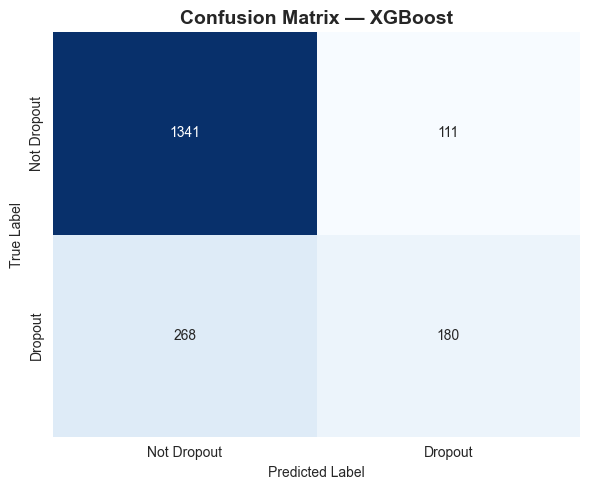

In [9]:
# ── 7. Confusion Matrix Plot 
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Not Dropout', 'Dropout'],
    yticklabels=['Not Dropout', 'Dropout'],
)
plt.title('Confusion Matrix — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(models_dir / 'confusion_matrix_xgboost.png', dpi=150)
plt.show()

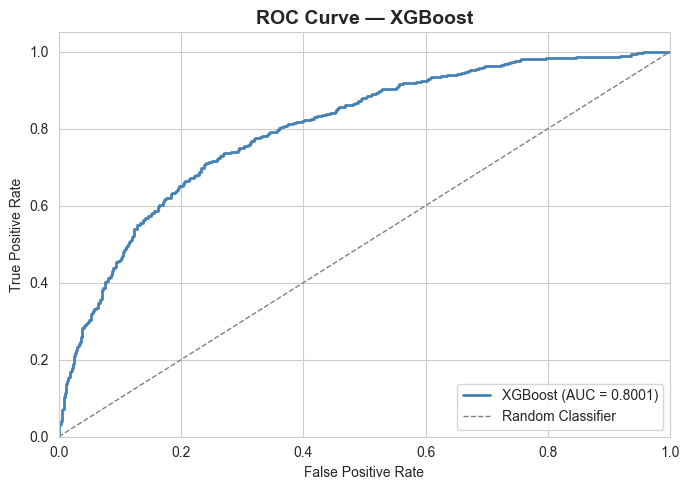

AUC Score: 0.8001


In [10]:
#  8. ROC and AUC Curve 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(models_dir / 'roc_curve_xgboost.png', dpi=150)
plt.show()

print(f'AUC Score: {auc_score:.4f}')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11996\497756485.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


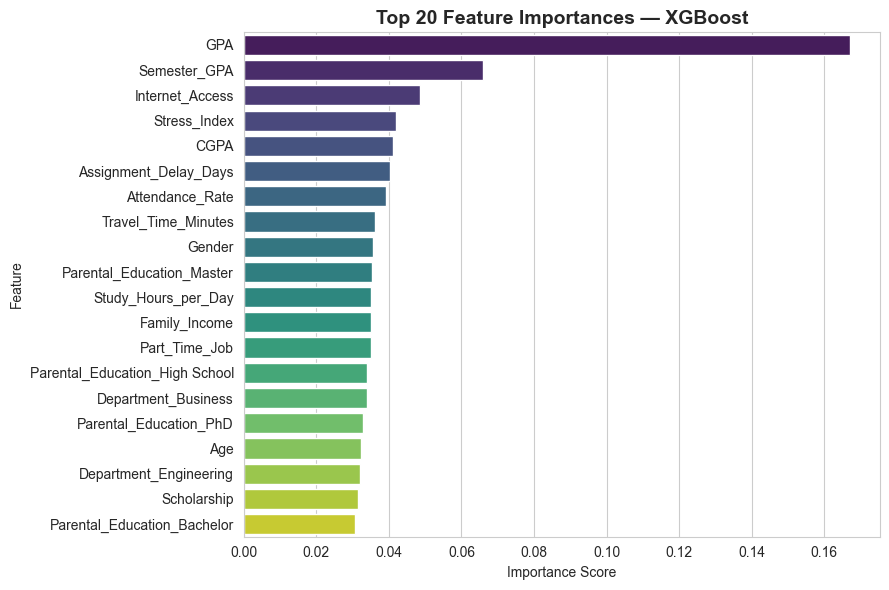

In [14]:
# ── 9. Feature Importance Plot 
booster        = xgb_pipeline.named_steps['model']
raw_importance = booster.feature_importances_

# Reconstruct feature names after one-hot encoding
ohe_features = (
    xgb_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
    .tolist()
    if categorical_features else []
)
all_feature_names = numeric_features + ohe_features

importance_df = (
    pd.DataFrame({'feature': all_feature_names, 'importance': raw_importance})
    .sort_values('importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(models_dir / 'feature_importance_xgboost.png', dpi=150)
plt.show()

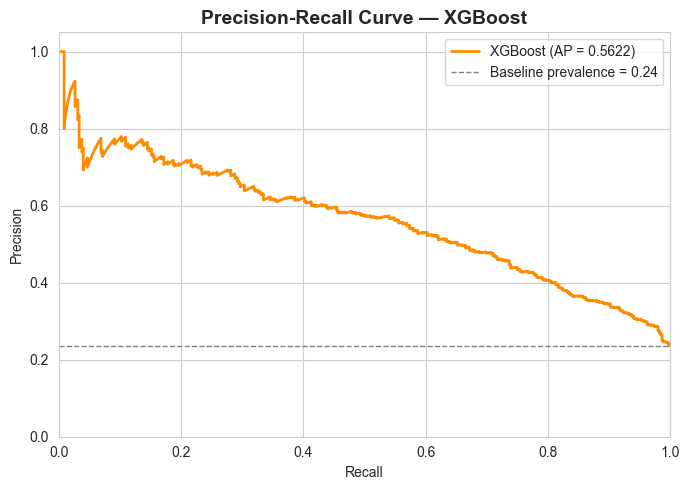

Average Precision Score: 0.5622


In [15]:
# ── 10. Precision-Recall Curve 
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision         = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'XGBoost (AP = {avg_precision:.4f})')
plt.axhline(y=y_test.mean(), color='grey', linestyle='--', lw=1,
            label=f'Baseline prevalence = {y_test.mean():.2f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(models_dir / 'precision_recall_xgboost.png', dpi=150)
plt.show()

print(f'Average Precision Score: {avg_precision:.4f}')